# Utvidelse 07 — Levetidskost per faktisk levert MWh for sjeldne hendelser

LCOE / LCOS for batterier oppgis nesten alltid med **høye sykluser per år** (300+). Det er fordi nevneren — levert energi over levetiden — vokser med syklustall.

For en park dimensjonert for **sjelden Dunkelflaute** brukes parken kanskje **én gang hvert femte år**. Da blir levetidskost per faktisk levert MWh dramatisk høyere.

Denne notebooken regner LCOS for tre roller:

1. **Daglig arbitrasje** (300 syk./år)
2. **Ukentlig fleksibilitet** (50 syk./år)
3. **Dunkelflaute-reserve** (0,2 syk./år)


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
candidates = [HERE / "data" / "defaults.json", HERE.parent.parent / "data" / "defaults.json", HERE.parent / "data" / "defaults.json"]
defaults = json.loads(next(p for p in candidates if p.exists()).read_text())["defaults"]

capex_usd_per_kwh = defaults["turnkey_bess_cost_usd_per_kwh"]   # ~117
opex_pct_per_year = 0.02
discount_rate     = 0.07
lifetime_years    = 15
round_trip_eta    = 0.85

dunkelflaute_twh = defaults["residual_gap_gw"] * 24 * defaults["event_days"] / 1000
dunkelflaute_oslo_years = twh_to_oslo_years(dunkelflaute_twh)
print(f"Basis-hendelsen leverer {dunkelflaute_twh:.1f} TWh = {dunkelflaute_oslo_years:.1f} Oslo-år.")


## Oslo-år som felles målestokk

I alle utvidelsene bruker vi samme norske normalisering: **Oslo ≈ 1 GW kontinuerlig ≈ 8,76 TWh per år**. Det gjør GW- og TWh-tall lettere å lese uten å blande effekt med energi.


In [ ]:
HOURS_PER_YEAR = 8760

anchors = {
    "Norsk husholdning": {"energy_kwh_per_year": 14_700, "source": "SSB 2024"},
    "Bergen kommune": {"energy_twh_per_year": 3.4898, "source": "SSB tabell 14490, 2024"},
    "Oslo kommune": {"energy_twh_per_year": 8.7589, "source": "SSB tabell 14490, 2024"},
    "Statkraft Norge": {"energy_twh_per_year": 51.2, "source": "Statkraft 2025"},
    "Norge forbruk inkl. tap": {"energy_twh_per_year": 139.2, "source": "Statnett 2025"},
    "Norge produksjon": {"energy_twh_per_year": 162.0, "source": "Statnett 2025"},
}


def twh_to_average_gw(twh_per_year):
    return twh_per_year / (HOURS_PER_YEAR / 1000)


def gw_to_twh_per_year(gw):
    return gw * HOURS_PER_YEAR / 1000


def twh_to_oslo_years(twh):
    return twh / anchors["Oslo kommune"]["energy_twh_per_year"]


def oslo_average_gw():
    return twh_to_average_gw(anchors["Oslo kommune"]["energy_twh_per_year"])


def describe_energy(twh):
    return {
        "TWh": twh,
        "Oslo-år": twh_to_oslo_years(twh),
        "Bergen-år": twh / anchors["Bergen kommune"]["energy_twh_per_year"],
        "Statkraft Norge-år": twh / anchors["Statkraft Norge"]["energy_twh_per_year"],
        "Norge-forbruksår": twh / anchors["Norge forbruk inkl. tap"]["energy_twh_per_year"],
        "Gjennomsnittlig GW i ett år": twh_to_average_gw(twh),
    }


## Annuitet og energi-throughput

Vi bruker standard annuitetsformel og antar at man får utnytte 90 % av installert kWh per syklus.


In [2]:
def annuity_factor(r: float, n: int) -> float:
    return r * (1 + r) ** n / ((1 + r) ** n - 1)

def lcos(cycles_per_year: float, capex_usd_per_kwh: float = capex_usd_per_kwh) -> float:
    af = annuity_factor(discount_rate, lifetime_years)
    annual_capex = capex_usd_per_kwh * af
    annual_opex  = capex_usd_per_kwh * opex_pct_per_year
    delivered_per_kwh_per_year = cycles_per_year * 0.90 * round_trip_eta
    if delivered_per_kwh_per_year <= 0:
        return float("inf")
    return (annual_capex + annual_opex) / delivered_per_kwh_per_year

scenarios = [
    {"role": "Daglig arbitrasje",     "cycles_per_year": 300},
    {"role": "Ukentlig fleksibilitet","cycles_per_year":  50},
    {"role": "Dunkelflaute-reserve",  "cycles_per_year":   0.2},
]
for s in scenarios:
    s["LCOS_USD_per_kWh"] = lcos(s["cycles_per_year"])
    s["LCOS_USD_per_MWh"] = s["LCOS_USD_per_kWh"] * 1000
df = pd.DataFrame(scenarios)
df


,role,cycles_per_year,LCOS_USD_per_kWh,LCOS_USD_per_MWh
0,Daglig arbitrasje,300.0,0.066170,66.169809
1,Ukentlig fleksibilitet,50.0,0.397019,397.018852
2,Dunkelflaute-reserve,0.2,99.254713,99254.713007


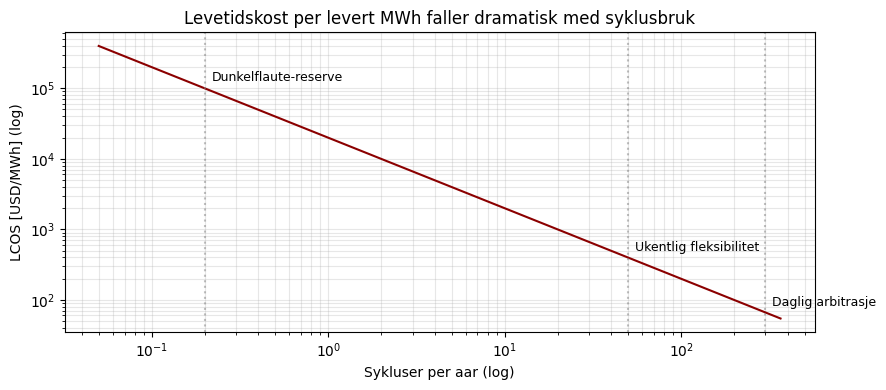

In [3]:
xs = np.geomspace(0.05, 365, 200)
ys = [lcos(c) * 1000 for c in xs]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xs, ys, color="darkred")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sykluser per år (log)")
ax.set_ylabel("LCOS [USD/MWh] (log)")
ax.set_title("Levetidskost per levert MWh faller dramatisk med syklusbruk")
for s in scenarios:
    ax.axvline(s["cycles_per_year"], linestyle=":", color="grey", alpha=0.5)
    ax.annotate(s["role"], xy=(s["cycles_per_year"], s["LCOS_USD_per_MWh"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## Hva betyr det i kroner?


In [4]:
usd_to_nok = 11.0
for s in scenarios:
    nok_per_kwh = s["LCOS_USD_per_MWh"] * usd_to_nok / 1000
    print(f"{s['role']:>30s}: {s['LCOS_USD_per_MWh']:>9.0f} USD/MWh = {nok_per_kwh:>6.2f} kr/kWh")


             Daglig arbitrasje:        66 USD/MWh =   0.73 kr/kWh
        Ukentlig fleksibilitet:       397 USD/MWh =   4.37 kr/kWh
          Dunkelflaute-reserve:     99255 USD/MWh = 1091.80 kr/kWh


## Læring

- Et batteri **brukt sjelden** har levetidskost per levert MWh i størrelsesorden **flere tusen USD/MWh** — to til tre størrelsesordener over markedspris.
- Det er nesten umulig å forsvare slik kapital uten **stablede inntekter**: frekvens, intra-dag, kapasitetsmarked, *og* sjelden krise-bruk.
- For ren Dunkelflaute-rolle (få sykluser per år) er **andre teknologier** typisk billigere per faktisk levert MWh:
  - Hydrogen / syntetisk metan / ammoniakk i eksisterende gassturbin: kapital deles med daglig drift, brensel betales bare når det brukes.
  - Vannmagasin: marginalkost ≈ 0, bare **opportunitetskost** mot annen sesong.
- Det er **denne** beregningen, ikke USD/kWh-prisen alene, som avgjør om en teknologi hører hjemme i Dunkelflaute-rollen.
